# Line Segmentation Testing
Line segmentation in OCR means detecting lines from the recognized text.

References:
1. https://stackoverflow.com/questions/71754254/text-line-segmentation-using-opencv-python  


# Using OpenCV

In [2]:
%pip install opencv-python

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.1.2 -> 24.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import cv2
from matplotlib import pyplot as plt

In [4]:
from glob import glob
import pymupdf  # PyMuPDF

pdfs = glob(r"C:\Users\ashar\repos\ai4doc\pdfs\*.pdf")

# Open the PDF file
doc = pymupdf.open(pdfs[0])

# Select the page
page_number = 0  # page numbers start from 0
page = doc.load_page(page_number)

# Render page to an image
pix = page.get_pixmap()

# Save the image
output_image = "output_image.png"
pix.save(output_image)

print(f"Page {page_number + 1} has been saved as {output_image}")

Page 1 has been saved as output_image.png


In [5]:
img = cv2.imread(output_image)
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
ret, thresh2 = cv2.threshold(img_gray, 150, 255, cv2.THRESH_BINARY_INV)
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (150,2))
mask = cv2.morphologyEx(thresh2, cv2.MORPH_DILATE, kernel)


In [6]:
print(mask)

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [7]:
bboxes = []
bboxes_img = img.copy()
contours = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contours = contours[0] if len(contours) == 2 else contours[1]
for cntr in contours:
    x,y,w,h = cv2.boundingRect(cntr)
    cv2.rectangle(bboxes_img, (x, y), (x+w, y+h), (0,0,255), 1)
    bboxes.append((x,y,w,h))

In [8]:
bboxes

[(0, 593, 332, 32),
 (0, 559, 194, 12),
 (0, 502, 231, 12),
 (0, 488, 590, 12),
 (0, 475, 608, 12),
 (0, 461, 598, 12),
 (0, 433, 226, 9),
 (16, 391, 240, 12),
 (16, 378, 596, 12),
 (16, 364, 586, 12),
 (0, 351, 568, 12),
 (0, 323, 290, 12),
 (0, 309, 231, 9),
 (0, 295, 328, 12),
 (0, 282, 192, 12),
 (0, 268, 216, 9),
 (0, 223, 217, 2),
 (0, 213, 216, 9),
 (0, 158, 216, 12),
 (370, 86, 235, 34),
 (371, 70, 232, 15),
 (0, 69, 181, 15),
 (371, 54, 212, 8),
 (371, 46, 215, 6),
 (0, 46, 181, 21),
 (371, 37, 197, 8)]

In [9]:
# Optionally save the result image
cv2.imwrite('image_with_line_segmentation.png', bboxes_img)

True

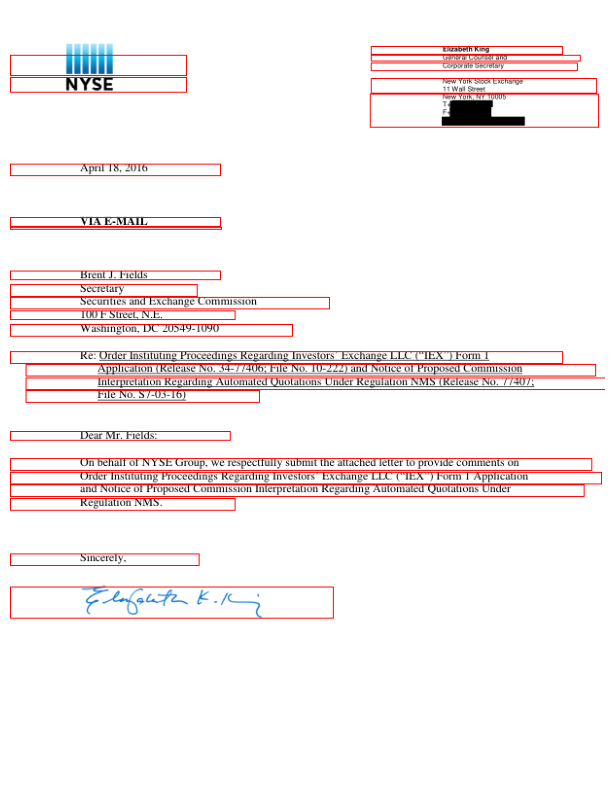

In [10]:
# Step 7: Convert BGR to RGB for Matplotlib
image_rgb = cv2.cvtColor(bboxes_img, cv2.COLOR_BGR2RGB)

# Step 8: Display the image using Matplotlib
plt.figure(figsize=(10, 10))
plt.imshow(image_rgb)
plt.axis('off')  # Turn off axis labels
plt.show()

# Using PyMuPDF

In [16]:
import pymupdf 

# Open the PDF file
doc = pymupdf.open(pdfs[0])

# Iterate through the pages
for page_num in range(len(doc)):
    page = doc[page_num]
    blocks = page.get_text("dict")['blocks']
    
    for block in blocks:
        if block['type'] == 0:  # Text block
            for line in block['lines']:
                # Initialize variables to store the coordinates of the merged bounding box
                x_min, y_min = float('inf'), float('inf')
                x_max, y_max = float('-inf'), float('-inf')
                
                for span in line['spans']:
                    bbox = span['bbox']
                    x_min = min(x_min, bbox[0])
                    y_min = min(y_min, bbox[1])
                    x_max = max(x_max, bbox[2])
                    y_max = max(y_max, bbox[3])
                
                # Optionally, draw the bounding box on the PDF page
                rect = pymupdf.Rect(x_min, y_min, x_max, y_max)
                page.draw_rect(rect, color=(1, 0, 0), width=0.5)

    # Optionally, save the annotated PDF
    doc.save('annotated_output.pdf')


In [21]:
block.keys()

dict_keys(['number', 'type', 'bbox', 'lines'])

In [3]:
import pymupdf 

# Function to check if two lines belong to the same paragraph
def is_same_paragraph(line1, line2, threshold=5):
    # Compare the vertical positions (y-coordinates)
    y1_bottom = line1['bbox'][3]
    y2_top = line2['bbox'][1]
    
    # If the gap between the bottom of line1 and the top of line2 is small, they are in the same paragraph
    return y2_top - y1_bottom < threshold

# Function to merge bounding boxes
def merge_bboxes(lines):
    x_min = min(line['bbox'][0] for line in lines)
    y_min = min(line['bbox'][1] for line in lines)
    x_max = max(line['bbox'][2] for line in lines)
    y_max = max(line['bbox'][3] for line in lines)
    
    return [x_min, y_min, x_max, y_max]

# Open the PDF file
# doc = pymupdf.open(r"C:\Users\ashar\repos\ai4doc\pdfs\s70322-20161798-330674.pdf")
doc = pymupdf.open(r"C:\Users\ashar\repos\ai4doc\pdfs\s71915-1872954-156785.pdf")

# Iterate through the pages
for page_num in range(len(doc)):
    page = doc[page_num]
    test = page.get_text()

    # Extract text from the page
    if test=='':
        full_tp = page.get_textpage_ocr(flags=0, dpi=300, full=True)
        text = page.get_text("dict", textpage=full_tp)

    else:
        partial_tp = page.get_textpage_ocr(flags=0, full=False)
        text = page.get_text("dict")

    blocks = text['blocks']
    
    for block in blocks:
        if block['type'] == 0:  # Text block
            paragraphs = []
            current_paragraph = []
            
            for i, line in enumerate(block['lines']):
                if not " ".join([span['text'] for span in line['spans']]).strip() == "":
                    if i == 0:
                        current_paragraph.append(line)
                    else:
                        if len(current_paragraph) == 0:
                            current_paragraph.append(line)
                        elif is_same_paragraph(current_paragraph[-1], line):
                            current_paragraph.append(line)
                        else:
                            paragraphs.append(current_paragraph)
                            current_paragraph = [line]
                
            # Add the last paragraph
            if current_paragraph:
                paragraphs.append(current_paragraph)
            
            # Process each paragraph
            for paragraph in paragraphs:
                paragraph_bbox = merge_bboxes(paragraph)
                paragraph_text = " ".join(span['text'] for line in paragraph for span in line['spans'])

                print(f"Paragraph BBox on page {page_num+1}: {paragraph_bbox}")
                print(f"Paragraph Text: {paragraph_text}")

                # Optionally, draw the paragraph bounding box on the page
                rect = pymupdf.Rect(paragraph_bbox)
                page.draw_rect(rect, color=(0, 0, 1), width=0.5)

    # Optionally, save the annotated PDF
    doc.save('annotated_output_with_para.pdf')


Paragraph BBox on page 3: [108.0199966430664, 152.12002563476562, 116.8759994506836, 168.60801696777344]
Paragraph Text:   
Paragraph BBox on page 3: [108.0199966430664, 221.72000122070312, 116.8759994506836, 238.20799255371094]
Paragraph Text:   
Paragraph BBox on page 3: [108.0199966430664, 363.3500061035156, 116.8759994506836, 379.8380126953125]
Paragraph Text:   
Paragraph BBox on page 3: [108.0199966430664, 461.77001953125, 116.8759994506836, 478.2580261230469]
Paragraph Text:   
Paragraph BBox on page 3: [108.0199966430664, 574.5699462890625, 116.8759994506836, 591.0579833984375]
Paragraph Text:   
Paragraph BBox on page 5: [152.5399932861328, 230.41998291015625, 163.4032745361328, 242.41998291015625]
Paragraph Text: —
Paragraph BBox on page 5: [267.6499938964844, 559.9600219726562, 276.66650390625, 569.9199829101562]
Paragraph Text: —
Paragraph BBox on page 6: [247.25, 427.2699890136719, 258.11328125, 439.2699890136719]
Paragraph Text: —
Paragraph BBox on page 6: [416.82998

In [27]:
line

{'spans': [{'size': 12.0,
   'flags': 4,
   'font': 'Times New Roman',
   'color': 0,
   'ascender': 1.0529999732971191,
   'descender': -0.2809999883174896,
   'text': 'S',
   'origin': (196.8699951171875, 58.82000732421875),
   'bbox': (196.8699951171875,
    46.18400573730469,
    203.5419921875,
    62.19200897216797)},
  {'size': 9.600000381469727,
   'flags': 4,
   'font': 'Times New Roman',
   'color': 0,
   'ascender': 1.0529999732971191,
   'descender': -0.2809999883174896,
   'text': ' IM PSO N  ',
   'origin': (203.5419921875, 58.82000732421875),
   'bbox': (203.5419921875,
    48.71120834350586,
    252.2523956298828,
    61.517608642578125)},
  {'size': 12.0,
   'flags': 4,
   'font': 'Times New Roman',
   'color': 0,
   'ascender': 1.0529999732971191,
   'descender': -0.2809999883174896,
   'text': 'T',
   'origin': (253.77999877929688, 58.82000732421875),
   'bbox': (253.77999877929688,
    46.18400573730469,
    261.11199951171875,
    62.19200897216797)},
  {'size': 9.